
###  Assignment 1
##### Development Environment setup

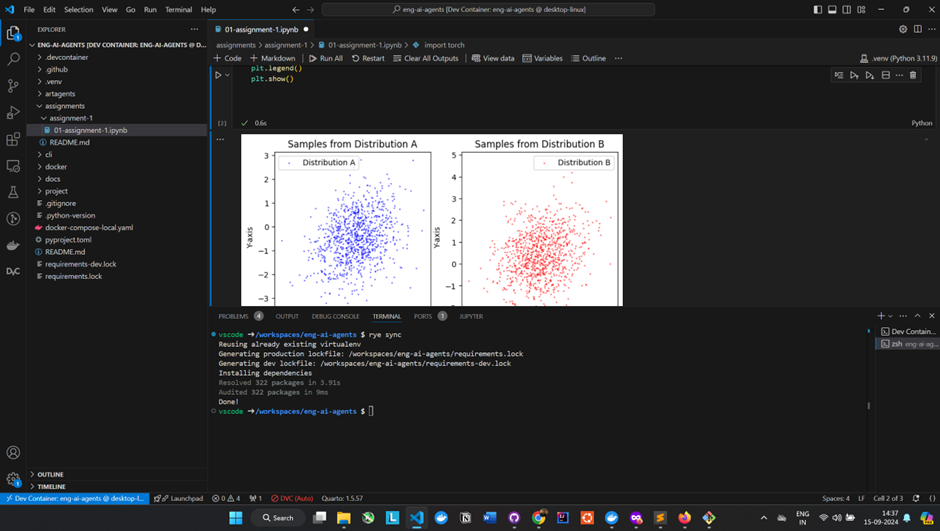

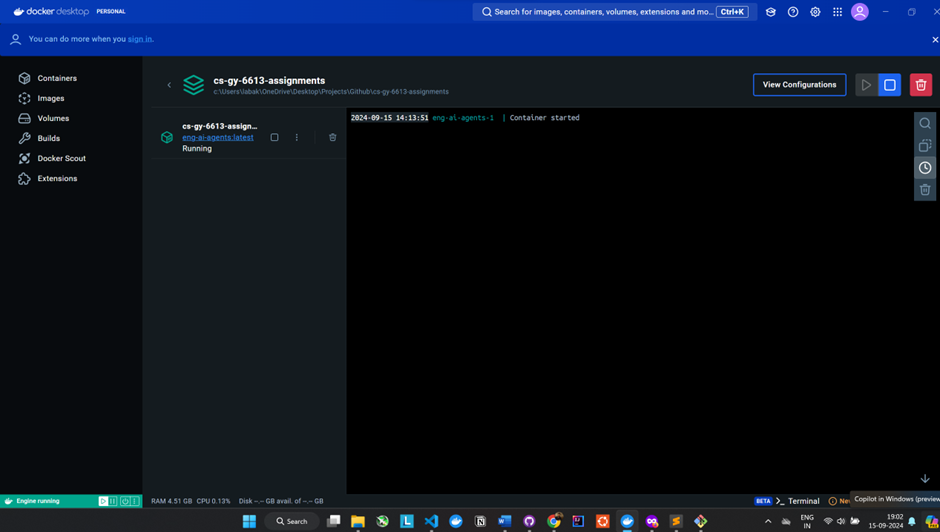






###  Assignment  2
##### Simulation of Multivariate Normal Distribution

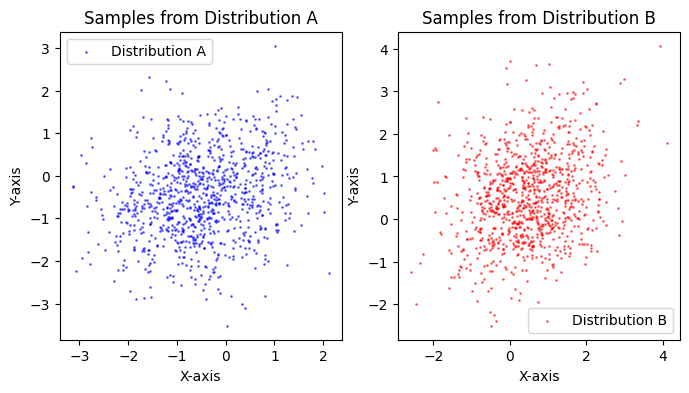

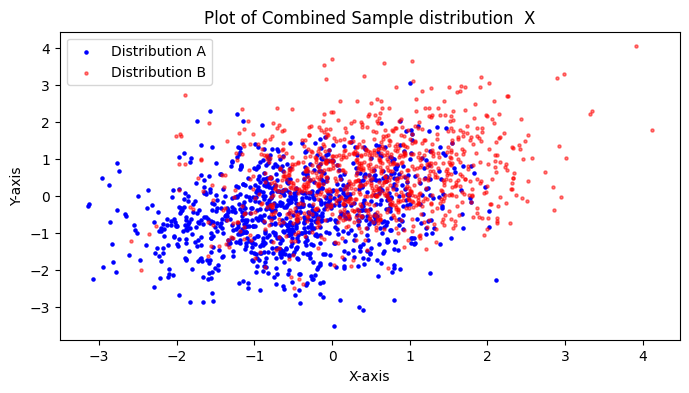

In [9]:
import torch
import matplotlib.pyplot as plt

# Using a NVIDIA GPU - hence using cuda
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# First Bivariate Normal distrubution parameters - according to the assignemnt
# we basically initialize a  1 D tensor , which contains the values for mean
# additionally the device = device serves as a way to run this using GPU
meanA = torch.tensor([-0.5, -0.5], device=device)
covariancMatrixA = torch.tensor([[1.0, 0.25], [0.25, 1.0]], device=device)
distributionA = torch.distributions.MultivariateNormal(meanA, covariancMatrixA)

# Now we are adding the parameters for the second one
meanB= torch.tensor([0.5, 0.5], device=device)
covariancMatrixB = covariancMatrixA # since the covariance in B is same as
distributionB = torch.distributions.MultivariateNormal(meanB, covariancMatrixB)

# Here we get the samples for both distributions
# we need a 1000 samples for both according to the question
samplesOfA = distributionA.sample((1000,))
samplesOfB = distributionB.sample((1000,))


# Scatter plot for samples from Distribution A


plt.figure(figsize=(8, 4))

samplesA_np = samplesOfA.cpu().numpy()
plt.subplot(1, 2, 1)
x_axis_of_A = samplesA_np[:, 0]
y_axis_of_A= samplesA_np[:, 1]
sizeA = 1
alphaA = 0.5 # transparency
plt.scatter(samplesA_np[:, 0], samplesA_np[:, 1], c='blue', s=sizeA, alpha=alphaA, label='Distribution A')
plt.title('Samples from Distribution A')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()


samplesB_np = samplesOfB.cpu().numpy()
plt.subplot(1, 2, 2)
x_axis_of_B = samplesB_np[:, 0]
y_axis_of_B = samplesB_np[:, 1]
sizeB = 1
alphaB = 0.5 # transparency
plt.scatter(x_axis_of_B, y_axis_of_B , c='red', s=sizeB, alpha=alphaB, label='Distribution B')
plt.title('Samples from Distribution B')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()


# now we will combine both into X

# Here we combine both into a single tensor X
X = torch.cat((samplesOfA, samplesOfB), dim=0)
labels = torch.cat((torch.zeros(1000, dtype=torch.long), torch.ones(1000, dtype=torch.long)), dim=0)
Xcpu = X.cpu().numpy()# Move combined samples to CPU for plotting
labelscpu = labels.cpu().numpy()

plt.figure(figsize=(8, 4))
plt.scatter(Xcpu[labelscpu == 0, 0], Xcpu[labelscpu == 0, 1], c='blue', s=5, label='Distribution A', alpha=1)
plt.scatter(Xcpu[labelscpu == 1, 0], Xcpu[labelscpu == 1, 1], c='red', s=5, label='Distribution B', alpha=0.5)

plt.title('Plot of Combined Sample distribution  X')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.show()




###  Assignment  3
##### K - means clustering


K Means algorithm ran for iterations =
14




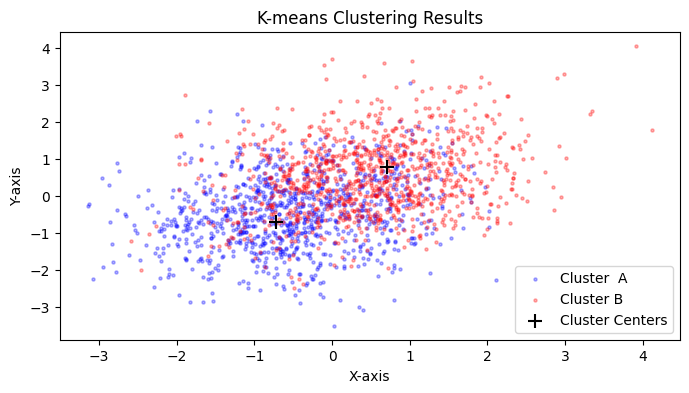

In [10]:

# Function to assign each point to the nearest cluster center
def GetLabels(X, centroid):
    distances = torch.cdist(X, centroid)  # Compute distances of each data point  to centroid- using builit in distance library of torch
    return torch.argmin(distances, dim=1)

# K-means clustering algorithm
def KMeansClustering(X, k, max_interations):

    # First of all we take two random indexes from our X (since we need a starting point for centroid)
    randomIndexes = torch.randint(0, X.size(0), (k,), dtype=torch.long)
    centroids =X[randomIndexes]

    # 1st iteration
    old_centroids = torch.empty(1,device = device)
    # Get Labels in the first iteration is not expected to give us much of a data , (unless the random index chosen was very very good)
    labels = GetLabels(X, centroids)
    iterations = 1

    # This is the main part of the algorithm
    # Basically we run the algorithm until the iterrations are oover the max , or unitl we get a value of centroid exactly equal to the previous
    while iterations < max_interations and not  torch.norm(centroids - old_centroids) == 0 :
        old_centroids = centroids.clone()
        labels = GetLabels(X, centroids)
        # Getting new centroid value based on the above clustering
        # Groups the centroids basically
        centroids =  torch.stack([X[labels == i].mean(dim=0) for i in range(k)])
        iterations  =    iterations +1

    print("\nK Means algorithm ran for iterations =")
    print(iterations)
    print("\n")
    return centroids, labels



k = 2 # Number of clusters - update this value if needed

# Centroids - gives us the center point basically
# labels will give us the two data we had
centroids, labels = KMeansClustering(X, k,100)


labels_cpu = labels.cpu().numpy()
centroids_cpu = centroids.cpu().numpy()

plt.figure(figsize=(8, 4))
plt.scatter(Xcpu[labelscpu == 0, 0], Xcpu[labelscpu == 0, 1], c='blue', s=5, label='Cluster  A', alpha=0.3)
plt.scatter(Xcpu[labelscpu == 1, 0], Xcpu[labelscpu == 1, 1], c='red', s=5, label='Cluster B', alpha=0.3)
plt.scatter(centroids_cpu [:, 0], centroids_cpu [:, 1], c='black', s=100, marker='+', label='Cluster Centers')  # Plot cluster centers
plt.title('K-means Clustering Results')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.show()

Assignment 3
PCA